# Research Workflow

This notebook demonstrates the research [workflow](https://langchain-ai.github.io/langgraph/tutorials/workflows/) that creates comprehensive reports through a series of focused steps. The system:

1. Uses a **graph workflow** with specialized nodes for each report creation stage
2. Enables user **feedback and approval** at critical planning points 
3. Produces a well-structured report with introduction, researched body sections, and conclusion

## From repo 

In [58]:
#To start a fresh venv, delete the old one in file explore
#Then use this command: python -m venv .venv
#Then activate it using python interpreter (ctr + shift + P)
#Select the venv path, then open new vs code terminal and you should see the (.venv)

In [59]:
%cd ..
%load_ext autoreload
%autoreload 2

c:\Users\vedan
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## From package 

In [60]:
! pip install -U -q open-deep-research

# Compile the Graph-Based Research Workflow

The next step is to compile the LangGraph workflow that orchestrates the report creation process. This defines the sequence of operations and decision points in the research pipeline.

In [61]:
import uuid
import os, getpass
import sys
sys.path.append('/path/to/open_deep_research/src')  # Add the src directory to the path

from IPython.display import Image, display, Markdown
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from legacy.graph import builder  # Import from legacy.graph instead

In [62]:
# Create a memory-based checkpointer and compile the graph
# This enables state persistence and tracking throughout the workflow execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

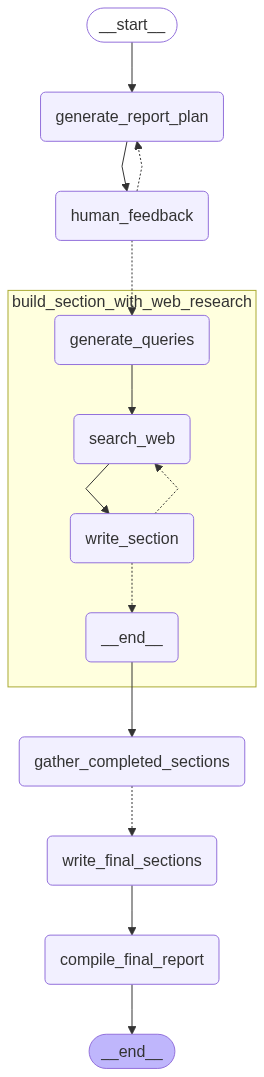

In [63]:
# Visualize the graph structure
# This shows the nodes and edges in the research workflow

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [64]:
# Helper function to set environment variables for API keys
# This ensures all necessary credentials are available for various services

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        

# Set the API keys used for any model or search tool selections below, such as:
#_set_env("OPENAI_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
#_set_env("TAVILY_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [ ]:
# Define report structure template and configure the research workflow
# This sets parameters for models, search tools, and report organization

REPORT_STRUCTURE = """Use this structure to create a introduction on the user-provided topic:

You are a research paper summarizer assisting professors when they want to learn
more about a specific field. Your task is to generate a compelling
introduction about the topic that the professor inputs. You are also a top level researcher
in this field. You are extremly specific and detial orientented and that is shown in the
introductions that you write.The introduction should effectively summarize the current state
of research, identify a research gap, and highlight the novelty and contribution of the paper.
Avoid including irrelevant details or overly technical explanations that are not
necessary for an introduction. Use intext MLA citations. 

The introduction should be structured as follows:

1.  **Background:** Begin with a broad overview of the topic the researcher enters and the significance of the research topic.
Explain the existing challenges and the importance of addressing the problem.

2.  **Literature Review and Research Gap:** Summarize relevant previous work in the field. Discuss the limitations of existing approaches
and clearly articulate the research gap that this paper aims to address.

3.  **Contribution and Novelty:** Present the proposed solution and explain how it is innovative and different from previous work.
Clearly state the key contributions of this research and its potential impact.

The introduction should be written in a formal and academic tone, using precise language and technical jargon where appropriate.
It should be concise yet comprehensive, effectively capturing the essence of the paper. For now do not add the third section
(Contribution and Novelty) and inplace of that just put a placeholder. 

Make sure :
--> To double check each fact before using mentioning it in the report. 
--> That you are not just combining facts, but rather explaining a topic with facts and turning the report into a cohesive story. 
--> To synthesize information from multiple sources to provide a nuanced view  
--> To cross-verify key numbers to ensure the most accurate figure is used, especially when multiple sources offer slightly different values.
--> That all numbers are consistant across the report. 

Here is an example of a well-written introduction:
***
On 4 July 2019, seismic activity initiated near Ridgecrest, California, and escalated over the next 2 hr
culminating with the occurrence of the first principle mainshock MW 6.4 at 17:33 UTC. It was followed by
an intense aftershock sequence leading up to the occurrence of the second mainshock, MW 7.1 at 03:19
UTC on 6 July 2019. The MW 6.4 and 7.1 mainshocks occurred closely in space (10‐km separation) and
activated a complex fault network composed of conjugate strike‐slip faults including the NW‐trending main
fault with about 65‐km‐long surface rupture and NE‐treading fault with ~15‐km‐long surface rupture
(Barnhart et al., 2019; Goldberg et al., 2019; Kendrick et al., 2019; Liu et al., 2019; Ross et al., 2019;
Figure 1). A high‐precision near real‐time catalog enables us to rapidly characterize the earthquake sequence
(Stewart, 1977), such as tracking seismicity evolution (Peng & Zhao, 2009; Ross et al., 2017; Zhang & Wen,
2015a) and identification of causative faults (Kao & Shan, 2007; Yang et al., 2009). The challenge is to build
a high‐precision earthquake catalog in near real‐time when the event rate becomes extreme.
Earthquake catalog building strongly depends on earthquake detection and location techniques. Two main
classes of methods are widely used in earthquake detection and location: pick‐based methods and
waveform‐based methods (Grigoli et al., 2018; Pesicek et al., 2014; Stewart, 1977; Zhang et al., 2019).
Independent of seismic phase picking, waveform‐based methods detect, associate, and locate earthquakes
simultaneously in a single step based on the delay‐and‐sum concept (Kao & Shan, 2004; Peng & Zhao,
2009; Shelly et al., 2007; Zhang & Wen, 2015b). They are sensitive to small earthquakes by maximizing
seismic energy or coherence but suffer from high computational costs due to their exhaustive searching in
space and time. Consequently, pick‐based methods are still the preferred solution for routine earthquake
monitoring due to their high computational efficiency (Grigoli et al., 2018). Seismic picks are conventionally
obtained from handpicking or automatic picking algorithms such as the short‐term average/long‐term
average picker (Allen, 1978; Withers et al., 1998). Recently, machine‐learning techniques have been
widely adopted in seismic phase picking, showing promise in both picking efficiency and picking accuracy
(e.g., Ross et al., 2018; Wang et al., 2019; Zhu et al., 2019; Zhu & Beroza, 2019). A high‐precision earthquake
catalog provides a window into the details of seismic fault structures. Various
techniques have been widely used to investigate fault structures after earthquakes occurred but hampered by
different aspects, such as: Focal mechanism inversion methods are only eligible to reveal the major fault
plane (e.g., Gephart & Forsyth, 1984); geodetic observations have little depth resolution (e.g., Ward &
Valensise, 1989); and on‐site surveys are not able to investigate buried faults (e.g., Xu et al., 2009).
Earthquakes may be accommodated on known or newly activated faults (Ross et al., 2019; Waldhauser,2009; Waldhauser & Ellsworth, 2002).
Thus, accurate earthquake locations play an important role in deli-neation of detailed seismic fault structures.
In this study, we first build sequential earthquake catalogs for the 2019 Ridgecrest earthquake sequence
from continuous waveform data using a machine‐learning picker, a newly developed earthquake association
and location algorithm, and two other high‐precision location programs. Then we compare our catalogs with
other available catalogs. Our results clearly reveal the seismicity migration in space and time and character-
ize seismic fault structures activated during the earthquake sequence.
***"""

# # Configuration option 1: Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            # "planner_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            # "writer_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# # Configuration option 2: DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

# Configuration option 3: Use OpenAI o3 for both planning and writing (selected option)
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "planner_model": "gpt-4o-mini",
                           "writer_provider": "openai",
                           "writer_model": "gpt-4o-mini",
                           "max_search_depth": 2,
                           "report_structure": REPORT_STRUCTURE,
                           }} 

# Define research topic about Model Context Protocol
topic = "Explore mars' shallow and deep interiors using seismic data and write me a proper research paper introduction about this topic."
# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Provides a broad overview of Mars' interiors and the significance of exploring both shallow and deep structures using seismic data.
Research needed: No


Section: Seismic Methods for Interior Exploration
Description: Discusses the seismic instruments and methods employed by the InSight mission to gather data about Mars' interior, focusing on the principles of wave propagation and analysis techniques used to interpret seismic data.
Research needed: Yes


Section: Findings on Shallow Interior of Mars
Description: Summarizes the findings regarding Mars' shallow interior, including insights into the crust's composition, structure, and the implications of detected seismic activities.
Research needed: Yes


Section: Insights into Deep Interior and Water Reservoirs
Description: Explores the evidence supporting the existence of water reservoirs deep beneath the surface of Mars, integrating findings from different studies and discussing their importance for future exploration and understanding of Martian geology.
Research needed: Yes


Section: Comparison of Martian and Terrestrial Seismology
Description: Compares the seismic activities and characteristics of Mars with those of Earth, highlighting differences and similarities in tectonic processes and what they reveal about each planet's history and structure.
Research needed: Yes


Section: Conclusion
Description: Summarizes the key findings and insights gained from exploring Mars' shallow and deep interiors through seismic data, considering the implications for future research and exploration missions.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# User Feedback Phase

* This allows for providing directed feedback on the initial report plan
* The user can review the proposed report structure and provide specific guidance
* The system will incorporate this feedback into the final report plan

In [66]:
# Submit feedback on the report plan
# The system will continue execution with the updated requirements

# Provide specific feedback to focus and refine the report structure
async for event in graph.astream(Command(resume=""), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: This section provides a brief overview of the importance of studying Mars' interiors using seismic data, highlighting the significance of understanding the planet’s geophysical characteristics and potential for supporting life.
Research needed: No


Section: Geophysical Characteristics of Mars
Description: This section details the current knowledge of Mars' internal structure derived from seismic data, including crust and mantle composition, and the potential existence of a liquid core. It references the findings of the InSight mission.
Research needed: Yes


Section: Seismic Data Analysis Techniques
Description: This section examines the methodologies employed to analyze seismic data collected by the InSight lander, including the use of P-waves and S-waves to infer the properties of the Martian subsurface and the challenges associated with interpreting this data.
Research needed: Yes


Section: Implications for Water and Life
Description: This section discusses the implications of seismic findings on the potential existence of liquid water in Mars' subsurface. It connects this possibility to theories about the potential for microbial life and habitability on Mars.
Research needed: Yes


Section: Case Studies of Seismic Events
Description: This section presents specific case studies of significant seismic events observed by the InSight mission, analyzing their effects on our understanding of Mars' internal structure and geology.
Research needed: Yes


Section: Future Directions in Martian Seismology
Description: This section explores potential future research directions based on current findings, including the need for additional missions and improved seismic technologies to further investigate Mars’ geology and potential for life.
Research needed: Yes


Section: Conclusion
Description: This concluding section summarizes the main findings of the report, reiterating the significance of using seismic data to unveil the mysteries of Mars' interior and potential for life.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# Final Approval Phase
* After incorporating feedback, approve the plan to start content generation

In [67]:
# Approve the final plan and execute the report generation
# This triggers the research and writing phases for all sections

# The system will now:
# 1. Research each section topic
# 2. Generate content with citations
# 3. Create introduction and conclusion
# 4. Compile the final report

async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name='Implications for Water and Life', description="This section discusses the implications of seismic findings on the potential existence of liquid water in Mars' subsurface. It connects this possibility to theories about the potential for microbial life and habitability on Mars.", research=True, content="## Implications for Water and Life\n\nRecent seismic data from NASA's InSight lander indicates the potential for liquid water beneath the Martian surface, offering new insights into the possibility of microbial life on Mars. Researchers Ikuo Katayama and Yuya Akamatsu suggest that seismic waves generated by marsquakes reveal a transition from dry rock to water-saturated rock at depths of 10 to 20 kilometers, which could facilitate the survival of microorganisms [1][2]. This interpretation challenges previous assumptions that these seismic signals were solely indicative of changes in rock p

In [68]:
# Display the final generated report
# Retrieve the completed report from the graph's state and format it for display

final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

Understanding the internal structure of Mars is critical for insights into its geological history and potential for supporting life. The NASA InSight mission has collected invaluable seismic data, revealing a thin crust, a large molten core, and the possibility of liquid water beneath the surface. By analyzing seismic waves, researchers can infer the properties of Mars' crust and mantle, and study natural events like marsquakes, which shed light on the planet's internal processes. This report synthesizes findings from various sections, including seismic data analysis techniques, implications for water and life, specific case studies of seismic events, and future directions in Martian seismology.

## Geophysical Characteristics of Mars

Recent findings from NASA's InSight mission have dramatically advanced our understanding of Mars' internal structure. Continuous seismic data collection since 2019 has revealed significant details regarding Martian crust, mantle, and core. The crust beneath the InSight lander is estimated to be between 15 to 25 miles (25 to 40 kilometers) thick, comprising three distinct layers. This contrasts with previous expectations of a thicker crust, indicating substantial geological variation across the planet [2][4].

Moreover, the seismic data indicates the presence of a large, liquid core with a radius of approximately 1,830 kilometers. This core, characterized by a lower density and the presence of lighter elements, suggests a molten state, which may be crucial in understanding Mars’ thermal evolution and the history of its magnetic field [3][4][5]. Additionally, the upper mantle exhibited characteristics of a stable lithosphere, suggesting it behaves differently compared to Earth, with less thermal activity driving geological processes [1][3].

In summary, insights into Mars' geological layers have not only refined our historical models but also prompted further inquiries into how these structures influence the planet's potential for hosting life in the past.

### Sources
[1] Crust, mantle and core structure of Mars from InSight seismic data: https://ui.adsabs.harvard.edu/abs/2021EPSC...15..512K/abstract  
[2] Science Highlights: https://science.nasa.gov/mission/insight/science-highlights/  
[3] Core of Mars is shockingly big, NASA's InSight mission reveals: https://www.nationalgeographic.com/science/article/nasa-insight-spacecraft-reveals-first-peek-inside-mars-center  
[4] Mars Interior Structure Revealed by InSight Seismic Data: https://www.astro.oma.be/en/mars-interior-structure-revealed-by-insight-seismic-data/  
[5] Thickness and structure of the martian crust from InSight seismic data: https://www.science.org/doi/10.1126/science.abf8966  

## Seismic Data Analysis Techniques

The analysis of seismic data from the InSight lander employs advanced methodologies primarily focused on P-waves and S-waves. P-waves, or primary waves, are compressional waves that travel faster and can move through both solid and liquid materials, whereas S-waves, or secondary waves, are slower and can only traverse solids. The differential travel times of these waves allow scientists to infer the properties of the Martian subsurface, including its composition and layering structures [1][4].

Challenges arise in data interpretation due to factors such as the shallow nature of Martian crust and the impact of surface conditions on seismic readings. For instance, the presence of uncemented sediments can influence wave velocities, complicating the analysis [7][8]. Furthermore, the unique seismic event signatures on Mars, ranging from marsquakes to impacts, can create noise that obscures valuable information [6][10]. To enhance clarity, researchers employ rock physics models to decode the seismic velocities and associated geological features [9][3]. As seismic data collection evolves, the ability to associate seismic waves with specific geological events significantly refines our understanding of the Martian interior.

### Sources
[1] Upper mantle structure of Mars from InSight seismic data - Science: https://www.science.org/doi/10.1126/science.abf2966  
[3] Seismology on Mars: An analysis of direct, reflected, and converted ...: https://www.sciencedirect.com/science/article/pii/S0031920122000127  
[4] InSight Landing Press Kit | Science: https://www.jpl.nasa.gov/news/press_kits/insight/landing/mission/science/  
[6] Potential Pitfalls in the Analysis and Structural Interpretation of ...: https://pubs.geoscienceworld.org/ssa/bssa/article-abstract/111/6/2982/608240/Potential-Pitfalls-in-the-Analysis-and-Structural  
[7] Surprise, Surprise: Subsurface Water on Mars Defies Expectations: https://today.ucsd.edu/story/surprise-surprise-subsurface-water-on-mars-defies-expectations  
[8] New Impacts on Mars: Systematic Identification and Association With ...: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL109133  
[9] Porosity and hydrous alteration of the Martian crust from InSight ...: https://www.sciencedirect.com/science/article/pii/S0031920125000779  
[10] How InSight Revealed the Heart of Mars: https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/  

## Implications for Water and Life

Recent seismic data from NASA's InSight lander indicates the potential for liquid water beneath the Martian surface, offering new insights into the possibility of microbial life on Mars. Researchers Ikuo Katayama and Yuya Akamatsu suggest that seismic waves generated by marsquakes reveal a transition from dry rock to water-saturated rock at depths of 10 to 20 kilometers, which could facilitate the survival of microorganisms [1][2]. This interpretation challenges previous assumptions that these seismic signals were solely indicative of changes in rock porosity or composition.

Further analysis of the SEIS (Seismic Experiment for Interior Structure) data reveals that liquid water could reside within porous rock layers, akin to Earth's aquifers [8]. The findings also imply that water could exist in sufficient volumes to create an ocean-like reservoir beneath the crust, which could be critical for understanding past and present habitability on Mars [6][8]. Given that liquid water is essential for life as we know it, these discoveries significantly enhance our understanding of Martian geology and the potential for microbial life in its subsurface environments.

### Sources
[1] Is Life Lurking Beneath Mars? New Seismic Study Says It's Possible: https://scitechdaily.com/is-life-lurking-beneath-mars-new-seismic-study-says-its-possible/  
[2] Marsquakes And Meteorites Unveil The Potential For Subterranean Alien Lifeforms On Mars: https://astrobiology.com/2025/03/marsquakes-and-meteorites-unveil-the-potential-for-subterranean-alien-lifeforms-on-mars.html  
[6] There Are Oceans Of Water On Mars. They're Just Too Deep To Tap: https://astrobiology.com/2024/08/there-are-oceans-of-water-on-mars-they-just-too-deep-to-tap.html  
[8] Scientists find hint of hidden liquid water ocean deep below Mars: https://www.livescience.com/space/mars/scientists-find-hint-of-hidden-liquid-water-ocean-deep-below-mars-surface

## Case Studies of Seismic Events

The InSight mission has significantly advanced our understanding of Mars' internal structure through the analysis of seismic events. Since its deployment in 2018, InSight has recorded over 900 seismic events, revealing Mars as a seismically active planet with numerous impacts and possible tectonic activities [5]. Among these events, notable studies have focused on the characterization of marsquakes and impact-induced seismic waves.

The seismic data captured by InSight has enabled scientists to determine the properties of the Martian crust and upper mantle with unprecedented precision [2]. For example, significant seismic signals from impact events have provided valuable insights into the composition and thickness of the Martian crust. By correlating observed seismic waves with their surface impact points, researchers can refine interior models that describe the planet's geological history [3][4]. As a result, the seismic analyses from InSight are crucial in understanding the geological processes that have shaped Mars over billions of years.

Moreover, these studies illustrate not only the activity within the planet but also integrate data on surface formations and past impact events to construct a comprehensive picture of Martian geology [7][8]. This synthesis of seismic data along with geological insight allows for a more holistic understanding of Mars and enhances our knowledge of terrestrial planet formation [6].

### Sources
[1] SEIS: Insight's Seismic Experiment for Internal Structure of Mars - https://research-information.bris.ac.uk/files/183175117/Lognonne_2019_Article_SEISInsightSSeismicExperimentF.pdf  
[2] Upper mantle structure of Mars from InSight seismic data - https://www.science.org/doi/10.1126/science.abf2966  
[3] Impact-Seismic Investigations of the InSight Mission - https://ntrs.nasa.gov/api/citations/20205003836/downloads/Daubar2018_Article_Impact-SeismicInvestigations_optimized.pdf  
[4] Geology of the InSight landing site on Mars - https://www.nature.com/articles/s41467-020-14679-1  
[5] Seismic sources of InSight marsquakes and seismotectonic - https://www.sciencedirect.com/science/article/pii/S0040195122002281  
[6] SEISmometer for the Mars-Mission Insight - https://www.mps.mpg.de/planetary-science/insight-seis  
[7] Seismology on Mars: An analysis of direct, reflected, and - https://www.sciencedirect.com/science/article/pii/S0031920122000127  
[8] Initial results from the InSight mission on Mars - https://www.researchgate.net/publication/339463051_Initial_results_from_the_InSight_mission_on_Mars  

## Future Directions in Martian Seismology

The future of Martian seismology is poised for significant advancements, propelled by the insights gathered from NASA's InSight mission. As InSight collected approximately 1,300 seismic events during its operational period, it has not only revealed Mars' interior structure but has also demonstrated the presence of seismic activity largely associated with volcanic regions like Cerberus Fossae, suggesting potential dormancy rather than extinction of Martian volcanism [10](https://www.polytechnique-insights.com/en/columns/space/why-do-earthquakes-rewrite-the-history-of-mars/). 

Future missions should prioritize the deployment of additional seismometric equipment to enhance spatial coverage. The integration of enhanced seismic technologies could refine our understanding of Mars' geological processes [1](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2019JE006353). Moreover, incorporating data from seismic observations, heat flow measurements, and magnetometry could provide a comprehensive picture of Mars' layered internal structure [4](https://www.sciencedirect.com/science/article/abs/pii/S0032063311003278).

Collaborative investigations, possibly coordinated with future missions like ESA’s ExoMars, which intends to deploy another seismometer, could maximize data collection. This partnership would yield invaluable seismic data and potentially reveal more about the planet's geological history and its capacity to support life [5](https://www.nature.com/articles/s41467-020-15251-7). Continued exploration is essential as it sheds light on the geophysical dynamics that shaped not only Mars but also other rocky planets.

### Sources
[1] On‐Deck Seismology: Lessons from InSight for Future Planetary ... - https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2019JE006353  
[2] [PDF] Final Report Package 2022 NASA Planetary Mission Senior Review ... - https://www.lpi.usra.edu/NASA-academies-resources/PMSR22-Final-Report-Package.pdf  
[3] InSight (Interior Exploration using Seismic Investigations, Geodesy ...) - https://www.eoportal.org/satellite-missions/insight  
[4] Future Mars geophysical observatories for understanding its internal ... - https://www.sciencedirect.com/science/article/abs/pii/S0032063311003278  
[5] NASA's InSight mission on Mars—first glimpses of the planet's ... - https://www.nature.com/articles/s41467-020-15251-7  
[6] New Impacts on Mars: Unraveling Seismic Propagation Paths ... - https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024GL110159  
[7] SEIS: Insight's Seismic Experiment for Internal Structure of Mars - https://link.springer.com/article/10.1007/s11214-018-0574-6  
[8] NASA's InSight mission on Mars—first glimpses of the planet's ... - https://www.bohrium.com/paper-details/nasa-s-insight-mission-on-mars-first-glimpses-of-the-planet-s-interior-from-seismology/812662951520501761-10026  
[9] [PDF] New Impacts on Mars: Unraveling Seismic Propagation Paths ... - https://eps.rutgers.edu/images/New_Impacts_on_Mars_Unraveling_Seismic_PropagationPaths_Through_a_Cerberus_Fossae_Impact_Detection.pdf  
[10] Mars: how studying earthquakes changed our vision of the red planet - https://www.polytechnique-insights.com/en/columns/space/why-do-earthquakes-rewrite-the-history-of-mars/  

# Exploring Mars' Shallow and Deep Interiors through Seismic Data

Understanding the internal structure of Mars is crucial in unraveling its geological history and potential for life. This report delves into the seismic data collected by NASA's InSight mission, illuminating the composition of the Martian crust, mantle, and core. Key findings include a liquid core and variations in crust thickness that challenge previous models. The analysis of seismic waves, including P-waves and S-waves, has led to insights about subsurface features and possible water reservoirs. By examining specific seismic events, we enhance our understanding of Mars' dynamic history and assess implications for astrobiology, setting the stage for future explorations of the Red Planet. 

## Conclusion

In summary, the InSight mission has significantly advanced our understanding of Mars’ internal structure through rigorous seismic data analysis. Findings revealed include the presence of a large liquid core and a crust that varies in thickness from 15 to 25 miles, underscoring the planet's geological diversity. The study of seismic events, such as marsquakes, has enhanced our understanding of Martian geology and indicates that liquid water may exist below the surface, raising the possibility of microbial life. Moving forward, advancing seismic techniques and further missions could unveil more insights into Mars' history and its potential for sustaining life. The integration of these findings suggests a more complex and vibrant Martian environment than previously understood. 

In [71]:
import os
import re # Import regular expression module
from IPython.display import FileLink, display

# Define the base filename for your report
base_report_filename = "generated_research_report"
file_extension = ".md"

# Define the directory to save the report (e.g., current directory)
output_directory = os.getcwd()
output_directory += "\github\open_deep_research2\src\legacy\\reports"

# --- Find the next available edition number ---
next_edition_number = 1
existing_reports = []

# List all files in the output directory
try:
    for filename in os.listdir(output_directory):
        # Check if the filename matches our pattern (e.g., generated_research_report_X.md)
        match = re.match(rf"^{re.escape(base_report_filename)}_(\d+){re.escape(file_extension)}$", filename)
        if match:
            # Extract the number and add it to our list
            existing_reports.append(int(match.group(1)))

    if existing_reports:
        # If reports exist, the next edition is the highest existing number + 1
        next_edition_number = max(existing_reports) + 1

except FileNotFoundError:
    print(f"Directory not found: {output_directory}. Assuming first report.")
except Exception as e:
    print(f"Error while checking existing reports: {e}. Starting with edition 1.")

# Construct the new filename with the edition number
report_filename = f"{base_report_filename}_{next_edition_number}{file_extension}"
output_filepath = os.path.join(output_directory, report_filename)

print(f"Attempting to save report as: {report_filename} to: {output_filepath}")

try:
    with open(output_filepath, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"Report saved successfully to: {output_filepath}")

    # Verify if the file actually exists after writing
    if os.path.exists(output_filepath):
        print(f"Confirmation: File exists at {output_filepath}")
        # Create a download link - use the relative path for FileLink
        display(FileLink(report_filename))
    else:
        print(f"ERROR: File was NOT found at {output_filepath} immediately after writing.")

except PermissionError:
    print(f"ERROR: Permission denied. Cannot write to {output_filepath}.")
    print("Please check write permissions for this directory.")
except Exception as e:
    print(f"An unexpected error occurred while saving the report: {e}")


Attempting to save report as: generated_research_report_8.md to: c:\Users\vedan\github\open_deep_research2\src\legacy\reports\generated_research_report_8.md
Report saved successfully to: c:\Users\vedan\github\open_deep_research2\src\legacy\reports\generated_research_report_8.md
Confirmation: File exists at c:\Users\vedan\github\open_deep_research2\src\legacy\reports\generated_research_report_8.md


c:\Users\vedan\generated_research_report_8.md